# Logistic Regression — Banknote Authentication

The UCI Banknote Authentication dataset contains four
wavelet-transform statistics of scanned banknote images
(`variance`, `skewness`, `curtosis`, `entropy`) and a binary
label: genuine vs forged.

Logistic regression is a linear classifier that outputs
class probabilities via the sigmoid:

$$P(y=1 \mid x) = \sigma(w^\top x) = \frac{1}{1 + e^{-w^\top x}}$$

Parameters are estimated by minimizing the negative
log-likelihood (cross-entropy).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.datasets import find_data_file

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

In [2]:
from rice_ml.supervised_learning.linear import LogisticRegression
from rice_ml.processing.preprocessing import StandardScaler, train_test_split
from rice_ml.processing.metrics import (
    accuracy_score, confusion_matrix, precision_recall_f1, roc_auc_score,
)

df = pd.read_csv(find_data_file("BankNote_Authentication.csv"))
X = df.drop(columns=["class"]).to_numpy(dtype=float)
y = df["class"].to_numpy(dtype=int)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0,
)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

In [3]:
clf = LogisticRegression(alpha=0.01, learning_rate=0.5, max_iter=2000)
clf.fit(X_tr_s, y_tr)

y_pred = clf.predict(X_te_s)
y_proba = clf.predict_proba(X_te_s)[:, 1]
stats = precision_recall_f1(y_te, y_pred, positive_label=1)

print(f"Accuracy  = {accuracy_score(y_te, y_pred):.4f}")
print(f"AUC (ROC) = {roc_auc_score(y_te, y_proba):.4f}")
print(f"Precision = {stats['precision']:.4f}")
print(f"Recall    = {stats['recall']:.4f}")

Accuracy  = 0.9825
AUC (ROC) = 0.9992
Precision = 0.9867
Recall    = 0.9737


In [4]:
cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
pd.DataFrame(cm,
             index=["true class 0", "true class 1"],
             columns=["pred class 0", "pred class 1"])

,pred class 0,pred class 1
true class 0,188,2
true class 1,4,148


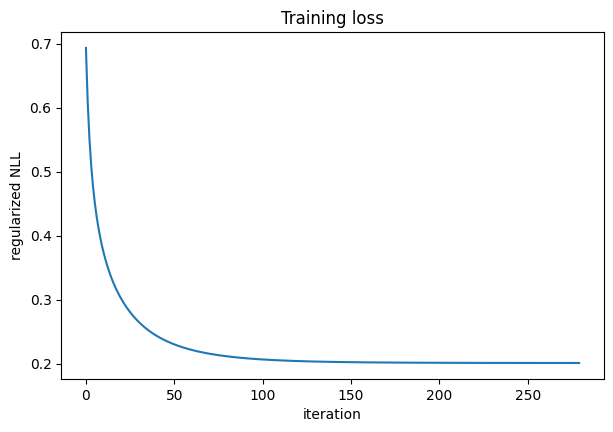

In [5]:
fig, ax = plt.subplots()
ax.plot(clf.loss_history_)
ax.set_xlabel("iteration")
ax.set_ylabel("regularized NLL")
ax.set_title("Training loss")
plt.show()

## Takeaways

- On this small tabular problem logistic regression is a
  strong linear baseline before trying ensembles.
- Feature scaling matters because the four inputs live on
  different scales.
- ROC-AUC summarizes ranking quality beyond a single
  0.5 decision threshold.